In [13]:
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt

In [14]:
w, x, y = sp.symbols("w x y")
prediction = w*x
loss = (y - prediction)**2
derivative = sp.diff(loss, w)
data = [
    (1, 2),
    (2, 4),
    (3, 6)
]
weight = 1
learning_rate = 0.1
weights = []
losses = []

In [15]:
print(prediction)
print(loss)
print(derivative)

w*x
(-w*x + y)**2
-2*x*(-w*x + y)


In [16]:
for epoch in range(5):
    print(f"Epoch : {epoch+1}")
    for x_value, y_value in data:
        prediction_value = prediction.subs({
            w:weight,
            x:x_value
        })
        loss_value = loss.subs({
            w:weight,
            x:x_value,
            y:y_value
        })
        gradient = derivative.subs({
            x:x_value,
            y:y_value,
            w:weight
        })

        weights.append(float(weight))
        losses.append(float(loss_value))

        weight = weight - learning_rate * gradient

Epoch : 1
Epoch : 2
Epoch : 3
Epoch : 4
Epoch : 5


# Loss Surface :

In [17]:
w_values = np.linspace(0,3, 100)
w_values

array([0.        , 0.03030303, 0.06060606, 0.09090909, 0.12121212,
       0.15151515, 0.18181818, 0.21212121, 0.24242424, 0.27272727,
       0.3030303 , 0.33333333, 0.36363636, 0.39393939, 0.42424242,
       0.45454545, 0.48484848, 0.51515152, 0.54545455, 0.57575758,
       0.60606061, 0.63636364, 0.66666667, 0.6969697 , 0.72727273,
       0.75757576, 0.78787879, 0.81818182, 0.84848485, 0.87878788,
       0.90909091, 0.93939394, 0.96969697, 1.        , 1.03030303,
       1.06060606, 1.09090909, 1.12121212, 1.15151515, 1.18181818,
       1.21212121, 1.24242424, 1.27272727, 1.3030303 , 1.33333333,
       1.36363636, 1.39393939, 1.42424242, 1.45454545, 1.48484848,
       1.51515152, 1.54545455, 1.57575758, 1.60606061, 1.63636364,
       1.66666667, 1.6969697 , 1.72727273, 1.75757576, 1.78787879,
       1.81818182, 1.84848485, 1.87878788, 1.90909091, 1.93939394,
       1.96969697, 2.        , 2.03030303, 2.06060606, 2.09090909,
       2.12121212, 2.15151515, 2.18181818, 2.21212121, 2.24242

In [18]:
loss_curve = []

In [19]:
for value in w_values:
    total_loss = 0
    for x_value, y_value in data:
        total_loss += (y_value - value * x_value)**2

    loss_curve.append(total_loss)

In [20]:
total_loss

np.float64(14.0)

In [21]:
print(len(weights))
print(len(losses))

15
15


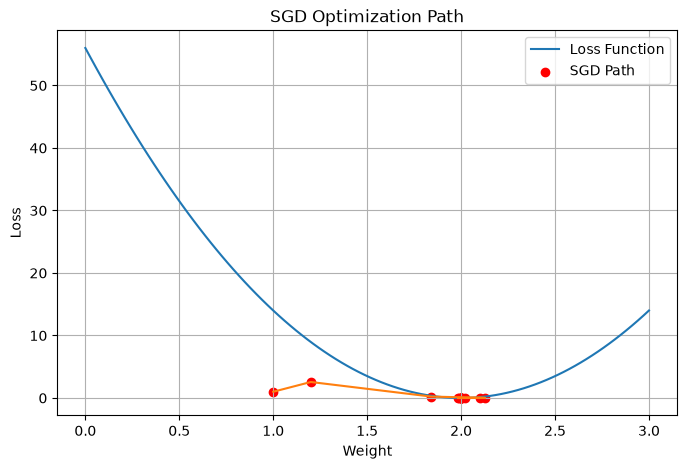

In [22]:
plt.figure(figsize=(8,5))
plt.plot(w_values, loss_curve, label="Loss Function")
plt.scatter(weights, losses,
            color="red",
            label="SGD Path")
plt.plot(weights, losses)
plt.xlabel("Weight")
plt.ylabel("Loss")
plt.title("SGD Optimization Path")
plt.legend()
plt.grid(True)
plt.show()